<a href="https://colab.research.google.com/github/CLizou/tests/blob/branch/linearRegressionModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files 
  
  
uploaded = files.upload()

Saving tests_ML.csv to tests_ML.csv


   position  attente
0       1.0     30.1
1       2.0     30.9
2       3.0     45.0
position    1.00000
attente     8.38113
dtype: float64
Defined the create_model and traing_model functions.
Defined the plot_the_model and plot_the_loss_curve functions.
Epoch 1/30


/usr/local/lib/python3.7/dist-packages/keras/optimizer_v2/rmsprop.py:130: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(RMSprop, self).__init__(name, **kwargs)


1/1 [==============================] - 1s 658ms/step - loss: 1152.1403 - root_mean_squared_error: 33.9432
Epoch 2/30
1/1 [==============================] - 0s 8ms/step - loss: 1145.5431 - root_mean_squared_error: 33.8459
Epoch 3/30
1/1 [==============================] - 0s 10ms/step - loss: 1140.7758 - root_mean_squared_error: 33.7754
Epoch 4/30
1/1 [==============================] - 0s 9ms/step - loss: 1136.7950 - root_mean_squared_error: 33.7164
Epoch 5/30
1/1 [==============================] - 0s 8ms/step - loss: 1133.2695 - root_mean_squared_error: 33.6641
Epoch 6/30
1/1 [==============================] - 0s 7ms/step - loss: 1130.0453 - root_mean_squared_error: 33.6161
Epoch 7/30
1/1 [==============================] - 0s 7ms/step - loss: 1127.0366 - root_mean_squared_error: 33.5714
Epoch 8/30
1/1 [==============================] - 0s 7ms/step - loss: 1124.1901 - root_mean_squared_error: 33.5289
Epoch 9/30
1/1 [==============================] - 0s 8ms/step - loss: 1121.4701 - root_m

ValueError: ignored

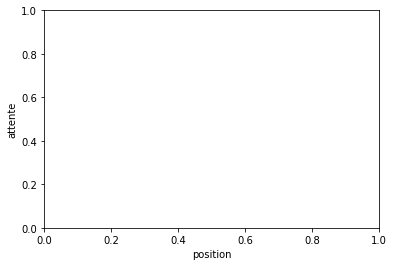

In [10]:
#using TensorFlow 2.x sur Colab
%tensorflow_version 2.x

#import librairies
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt

#import dataset
training_df = pd.read_csv(filepath_or_buffer='tests_ML.csv')
print(training_df.to_string())

#dataset analysis
std=training_df.std()
print(std)

#@title Define the functions that build and train a model
def build_model(my_learning_rate):
  """Create and compile a simple linear regression model."""
  # Most simple tf.keras models are sequential.
  model = tf.keras.models.Sequential()

  # Describe the topography of the model.
  # The topography of a simple linear regression model
  # is a single node in a single layer.
  model.add(tf.keras.layers.Dense(units=1, 
                                  input_shape=(1,)))

  # Compile the model topography into code that TensorFlow can efficiently
  # execute. Configure training to minimize the model's mean squared error. 
  model.compile(optimizer=tf.keras.optimizers.RMSprop(lr=my_learning_rate),
                loss="mean_squared_error",
                metrics=[tf.keras.metrics.RootMeanSquaredError()])

  return model        


def train_model(model, df, feature, label, epochs, batch_size):
  """Train the model by feeding it data."""

  # Feed the model the feature and the label.
  # The model will train for the specified number of epochs. 
  history = model.fit(x=df[feature],
                      y=df[label],
                      batch_size=batch_size,
                      epochs=epochs)

  # Gather the trained model's weight and bias.
  trained_weight = model.get_weights()[0]
  trained_bias = model.get_weights()[1]

  # The list of epochs is stored separately from the rest of history.
  epochs = history.epoch
  
  # Isolate the error for each epoch.
  hist = pd.DataFrame(history.history)

  # To track the progression of training, we're going to take a snapshot
  # of the model's root mean squared error at each epoch. 
  rmse = hist["root_mean_squared_error"]

  return trained_weight, trained_bias, epochs, rmse

print("Defined the create_model and traing_model functions.")

#@title Define the plotting functions
def plot_the_model(trained_weight, trained_bias, feature, label):
  """Plot the trained model against 200 random training examples."""

  # Label the axes.
  plt.xlabel(feature)
  plt.ylabel(label)

  # Create a scatter plot from 200 random points of the dataset.
  random_examples = training_df.sample(n=200)
  plt.scatter(random_examples[feature], random_examples[label])

  # Create a red line representing the model. The red line starts
  # at coordinates (x0, y0) and ends at coordinates (x1, y1).
  x0 = 0
  y0 = trained_bias
  x1 = 10000
  y1 = trained_bias + (trained_weight * x1)
  plt.plot([x0, x1], [y0, y1], c='r')

  # Render the scatter plot and the red line.
  plt.show()


def plot_the_loss_curve(epochs, rmse):
  """Plot a curve of loss vs. epoch."""

  plt.figure()
  plt.xlabel("Epoch")
  plt.ylabel("Root Mean Squared Error")

  plt.plot(epochs, rmse, label="Loss")
  plt.legend()
  plt.ylim([rmse.min()*0.97, rmse.max()])
  plt.show()  

print("Defined the plot_the_model and plot_the_loss_curve functions.")

# The following variables are the hyperparameters.
learning_rate = 0.01
epochs = 30
batch_size = 30

# Specify the feature and the label.
my_feature = "position"  # the total number of rooms on a specific city block.
my_label="attente" # the median value of a house on a specific city block.
# That is, you're going to create a model that predicts house value based 
# solely on total_rooms.  

# Discard any pre-existing version of the model.
my_model = None

# Invoke the functions.
my_model = build_model(learning_rate)
weight, bias, epochs, rmse = train_model(my_model, training_df, 
                                         my_feature, my_label,
                                         epochs, batch_size)

print("\nThe learned weight for your model is %.4f" % weight)
print("The learned bias for your model is %.4f\n" % bias )

plot_the_model(weight, bias, my_feature, my_label)
plot_the_loss_curve(epochs, rmse)